In [1]:
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import time
import logging
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import griddata
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
import scipy.sparse as ss
from scipy.stats import pearsonr
from scipy.ndimage import gaussian_filter
from sklearn.neighbors import KNeighborsRegressor

import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.profiler import profile, ProfilerActivity


import scanpy as sc

from TrajectoryNet import dataset
from TrajectoryNet.parse import parser
import TrajectoryNet.main as tnet_train
import TrajectoryNet.eval as tnet_eval
from TrajectoryNet.lib import utils
from TrajectoryNet.train_misc import (
    count_nfe,
    count_total_time,
    create_regularization_fns,
    get_regularization,
    append_regularization_to_log,
    build_model_tabular,
)

%matplotlib inline   

/nfs/turbo/umms-indikar/Cooper/conda_envs/scvelo/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# break

# Load adata

In [3]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/inputs/adata.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 322 ms, sys: 3.32 s, total: 3.65 s
Wall time: 5.28 s


AnnData object with n_obs × n_vars = 6895 × 15906
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz', 'velocyto_cell_id', 'cell_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'leiden', 'cluster_phase', 'early_g1_score', 'G1_stage', 'global_ordering', 'global_ordering_bin', 'velocity_self_tra

coords.shape=(6895, 50) vel.shape=(6895, 50)


/tmp/ipykernel_1951328/3328504580.py:31: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(


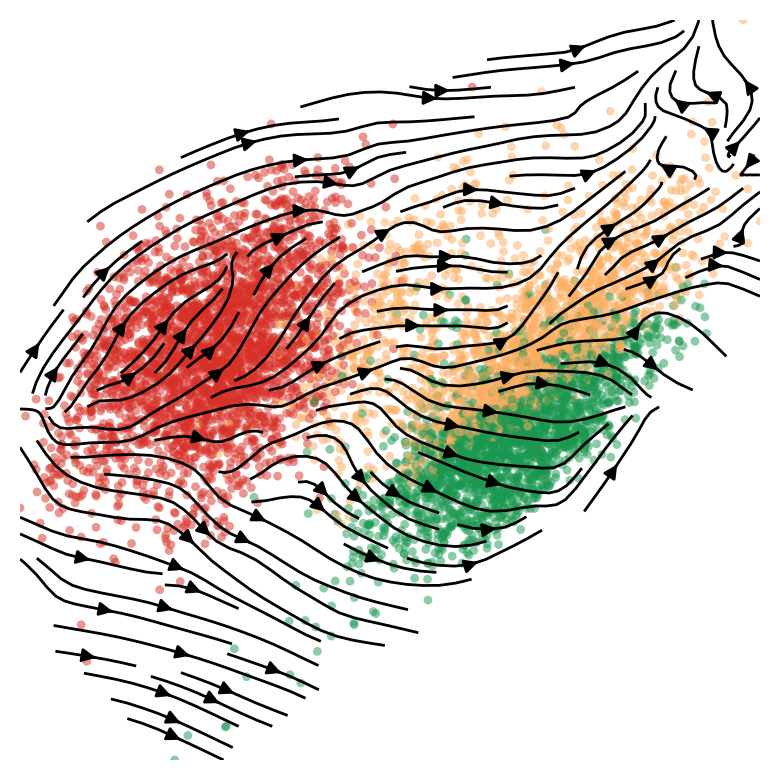

In [4]:
# Get coords and velocities
coords = adata.obsm["X_pca"]  # shape (n_cells, 2)
vel = -adata.obsm["velocity_pca"]  # shape (n_cells, 2)

print(f"{coords.shape=} {vel.shape=}")

x, y = coords[:, 0], coords[:, 1]
u, v = vel[:, 0], vel[:, 1]

# Create grid for interpolation
nbins = 25
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()
X, Y = np.meshgrid(
    np.linspace(xmin, xmax, nbins),
    np.linspace(ymin, ymax, nbins)
)

# Interpolate velocity field onto grid (density-weighted)
kde = gaussian_kde(np.vstack([x, y]))
weights = kde(np.vstack([x, y]))

U = griddata((x, y), u*weights, (X, Y), method="linear", fill_value=0)
V = griddata((x, y), v*weights, (X, Y), method="linear", fill_value=0)

# Background scatter (cells)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sns.scatterplot(
    x=x, y=y, s=10, ec='none',
    hue=adata.obs['cluster_phase'], 
    palette=adata.uns['cluster_phase_colors'],
    alpha=0.5, legend=False,
)

# Streamplot
plt.streamplot(
    X, Y, U, V,
    color="k",
    density=1.5,
    linewidth=1,
    arrowsize=1
)

# plt.title('PCA')
# plt.xlabel("PC 1")
# plt.ylabel("PC 2")

plt.xlabel("")
plt.ylabel("")
plt.xticks([])
plt.yticks([])
sns.despine(bottom=True, left=True)
plt.tight_layout()
plt.show()


In [5]:
adata.obs.columns

Index(['batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes',
       'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters',
       'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score',
       'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices',
       'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order',
       'mean_pseudotime', 'mean_order', 'nnz', 'velocyto_cell_id', 'cell_id',
       'initial_size_unspliced', 'initial_size_spliced', 'initial_size',
       'leiden', 'cluster_phase', 'early_g1_score', 'G1_stage',
       'global_orderi

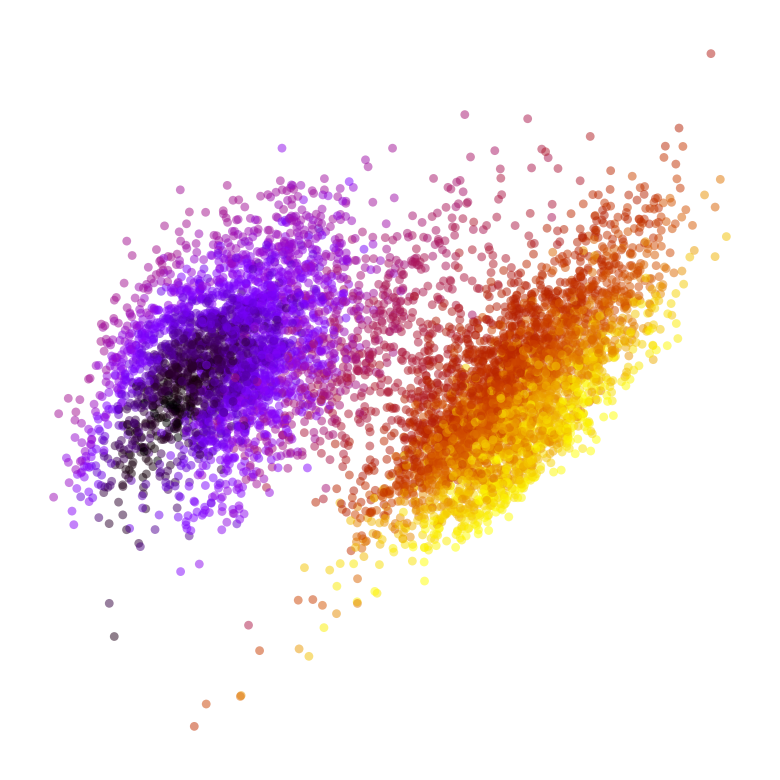

In [6]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sns.scatterplot(
    x=x, y=y, s=10, ec='none',
    hue=adata.obs['global_ordering'], 
    palette='gnuplot',
    alpha=0.5, legend=False,
)

plt.xlabel("")
plt.ylabel("")
plt.xticks([])
plt.yticks([])
sns.despine(bottom=True, left=True)
plt.tight_layout()
plt.show()

# Arguments

In [7]:
input = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/inputs/input_10comp_6time.npz"
# output = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/outputs"

args = {
    "dataset" : input,
    "embedding_name" : "pca", 
    "save" : output,
    "niters": 50,
    "max_dim": 20,
    "time_scale": 0.5,
    "use_density": True,
    "rtol": 1e-4, 
    "atol": 1e-5, 
    "top_k_reg": 1.5,
    "batch_size": 8192,
    "vecint": 1e-5, 
    "lr": 1e-2,
    "whiten" : True,
    "training_noise": 0.0,
    "weight_decay" : 1e-5,
}

def dict_to_cli(d):
    args = []
    for k, v in d.items():
        flag = f"--{k}"
        if isinstance(v, bool):
            if v:  # include flag only when True
                args.append(flag)
        else:
            args += [flag, str(v)]
    # parse dict with TrajectoryNet CLI parser for defaults           
    args = parser.parse_args(args)
    return args

args = dict_to_cli(args)
print(args)

Namespace(test=False, dataset='/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/inputs/input_10comp_6time.npz', use_growth=False, use_density=True, leaveout_timepoint=-1, layer_type='concatsquash', max_dim=20, dims='64-64-64', num_blocks=1, time_scale=0.5, train_T=True, divergence_fn='brute_force', nonlinearity='tanh', stochastic=False, alpha=0.0, solver='dopri5', atol=1e-05, rtol=0.0001, step_size=None, test_solver=None, test_atol=None, test_rtol=None, residual=False, rademacher=False, spectral_norm=False, batch_norm=False, bn_lag=0, niters=50, num_workers=8, batch_size=8192, test_batch_size=1000, viz_batch_size=2000, lr=0.01, weight_decay=1e-05, l1int=None, l2int=None, sl2int=None, dl2int=None, dtl2int=None, JFrobint=None, JdiagFrobint=None, JoffdiagFrobint=None, vecint=1e-05, use_magnitude=False, interp_reg=None, save='/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/outputs', save_freq=1000, viz_fre

# Set up model

In [8]:
def print_device_summary(device: torch.device):
    print(f"torch={torch.__version__} | cuda={torch.version.cuda} | "
          f"cudnn={torch.backends.cudnn.version()} | cuda_available={torch.cuda.is_available()}")

    if device.type == "cuda":
        idx = torch.cuda.current_device()
        name = torch.cuda.get_device_name(idx)
        cap = torch.cuda.get_device_capability(idx)
        n = torch.cuda.device_count()
        # memory
        to_gb = lambda b: b / (1024 ** 3)
        try:
            free, total = torch.cuda.mem_get_info(idx)  # PyTorch >=1.10
        except Exception:
            total = torch.cuda.get_device_properties(idx).total_memory
            free = total - torch.cuda.memory_allocated(idx)

        print(f"device=cuda:{idx} / {n} gpus | name={name}")
        print(f"capability={cap[0]}.{cap[1]} | mem_free={to_gb(free):.2f} GiB / mem_total={to_gb(total):.2f} GiB")
    else:
        print(f"device=cpu | threads={torch.get_num_threads()}")

In [9]:
# make output dir
utils.makedirs(args.save)

# set up device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print_device_summary(device)

# set up data
args.data = dataset.SCData.factory(args.dataset, args)

# set up timepoints
args.timepoints = args.data.get_unique_times()
args.int_tps = (np.arange(max(args.timepoints) + 1) + 1.0) * args.time_scale

print(f"{args.timepoints=}")
print(f"{args.int_tps=}")

# get regularization
regularization_fns, regularization_coeffs = create_regularization_fns(args)

# set model
model = build_model_tabular(
    args, 
    args.data.get_shape()[0], 
    regularization_fns).to(
        device
    )

# set up logger
logging.disable(logging.CRITICAL)
logger = logging.getLogger()

torch=2.7.1 | cuda=12.9 | cudnn=91200 | cuda_available=True
device=cuda:0 / 1 gpus | name=NVIDIA A100 80GB PCIe MIG 3g.40gb
capability=8.0 | mem_free=38.79 GiB / mem_total=39.25 GiB
args.timepoints=array([0, 1, 2, 3, 4, 5])
args.int_tps=array([0.5, 1. , 1.5, 2. , 2.5, 3. ])


# Train model

In [10]:
# def train_simple(device, args, model, logger):
    
#     optimizer = optim.Adam(
#         model.parameters(), 
#         lr=args.lr, 
#         weight_decay=args.weight_decay
#     )

#     time_meter = utils.RunningAverageMeter(0.93)
#     loss_meter = utils.RunningAverageMeter(0.93)
#     nfef_meter = utils.RunningAverageMeter(0.93)
#     nfeb_meter = utils.RunningAverageMeter(0.93)
#     tt_meter = utils.RunningAverageMeter(0.93)

#     full_data = (
#         torch.from_numpy(
#             args.data.get_data()[args.data.get_times() != args.leaveout_timepoint]
#         )
#         .type(torch.float32)
#         .to(device)
#     )

#     best_loss = float("inf")

#     end = time.time()
#     history = []
#     # for itr in range(1, args.niters + 1):
#     for itr in tqdm(range(1, args.niters + 1), total=args.niters, desc="TrajectoryNet"):
#         model.train()
#         optimizer.zero_grad()

#         # Train
#         loss = tnet_train.compute_loss(device, args, model, None, logger, full_data)
#         loss_meter.update(loss.item())

#         if len(regularization_coeffs) > 0:
#             # Only regularize on the last timepoint
#             reg_states = get_regularization(model, regularization_coeffs)
#             reg_loss = sum(
#                 reg_state * coeff
#                 for reg_state, coeff in zip(reg_states, regularization_coeffs)
#                 if coeff != 0
#             )
#             loss = loss + reg_loss
#         total_time = count_total_time(model)
#         nfe_forward = count_nfe(model)

#         loss.backward()
#         optimizer.step()

#         # Eval
#         nfe_total = count_nfe(model)
#         nfe_backward = nfe_total - nfe_forward
#         nfef_meter.update(nfe_forward)
#         nfeb_meter.update(nfe_backward)
#         time_meter.update(time.time() - end)
#         tt_meter.update(total_time)

#         history_record = {
#             "iter": itr,
#             "time_val": time_meter.val,
#             "time_avg": time_meter.avg,
#             "loss_val": loss_meter.val,
#             "loss_avg": loss_meter.avg,
#             "nfe_forward_val": nfef_meter.val,
#             "nfe_forward_avg": nfef_meter.avg,
#             "nfe_backward_val": nfeb_meter.val,
#             "nfe_backward_avg": nfeb_meter.avg,
#         }
#         history.append(history_record)

#         if itr % args.val_freq == 0 or itr == args.niters:
#             with torch.no_grad():
#                 tnet_train.train_eval(
#                     device, args, model, None, itr, best_loss, logger, full_data)
 
#         if itr % args.save_freq == 0:
#             chkpt = {
#                 "state_dict": model.state_dict(),
#             }
#             utils.save_checkpoint(
#                 chkpt,
#                 args.save,
#                 epoch=itr,
#             )
#         end = time.time()

#     return model, pd.DataFrame(history)

In [11]:
%%time

def trainTrajectoryNet(device, args, model, logger):
    torch.cuda.empty_cache()          

    # ---- fast math ----
    use_cuda = (device.type == "cuda")
    if use_cuda:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.set_float32_matmul_precision("high")  # enables TF32 fast paths
        torch.backends.cudnn.benchmark = True

    # compile (PyTorch 2.1+); comment out if not available
    try:
        model = torch.compile(model, mode="max-autotune")  # or "reduce-overhead"
        print(f"Compiled model.")
    except Exception:
        print(f"No model compilation.")
        pass

    # Optimizer 
    optimizer = optim.AdamW(
        model.parameters(),
        lr=args.lr, weight_decay=args.weight_decay,
        fused=use_cuda  # fused AdamW kernel on CUDA
    )

    # Meters
    time_meter = utils.RunningAverageMeter(0.93)
    loss_meter = utils.RunningAverageMeter(0.93)
    tt_meter   = utils.RunningAverageMeter(0.93)

    # one transfer to GPU; keep on device
    full_data = torch.from_numpy(
        args.data.get_data()[args.data.get_times() != args.leaveout_timepoint]
    ).to(device=device, dtype=torch.float32)
    full_data.requires_grad_(False)
    N = full_data.shape[0]

    best_loss = float("inf")
    end = time.time()
    history = []

    # optional: amp for speed if on CUDA
    scaler = torch.cuda.amp.GradScaler(enabled=use_cuda)

    for itr in range(1, args.niters + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        # ---- key change: sample a minibatch on-GPU ----
        bsz = min(args.batch_size, N)  # safe if batch_size > N
        idx = torch.randint(N, (bsz,), device=full_data.device)
        batch = full_data.index_select(0, idx)

        # loss on batch
        with torch.cuda.amp.autocast(enabled=use_cuda):
            loss = tnet_train.compute_loss(device, args, model, None, logger, batch)

            if len(regularization_coeffs) > 0:
                reg_states = get_regularization(model, regularization_coeffs)
                reg_loss = sum(
                    reg_state * coeff
                    for reg_state, coeff in zip(reg_states, regularization_coeffs)
                    if coeff != 0
                )
                loss = loss + reg_loss

        loss_meter.update(loss.detach().item())

        # backward/step
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # bookkeeping
        nfe_total = count_nfe(model)
        total_time = count_total_time(model)
        tt_meter.update(total_time)
        time_meter.update(time.time() - end)

        history.append({
            "iter": itr,
            "time_val": time_meter.val,      
            "time_avg": time_meter.avg,
            "loss_val": loss_meter.val,
            "loss_avg": loss_meter.avg,
            "nfe_total" : nfe_total,
        })

        # model eval
        if itr % args.val_freq == 0 or itr == args.niters:
            with torch.no_grad():
                tnet_train.train_eval(device, args, model, None, itr, best_loss, logger, full_data)

        if itr % args.save_freq == 0:
            utils.save_checkpoint({"state_dict": model.state_dict()}, args.save, epoch=itr)

        end = time.time()

    return model, pd.DataFrame(history)


"""
TRAINING
"""
model, history = trainTrajectoryNet(
    device, args, model, logger,
)

history.head()

No model compilation.


<timed exec>:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
<timed exec>:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


Density Loss 0.6305087804794312
Density Loss 0.603700578212738
Density Loss 0.6091691851615906
Density Loss 0.6127530336380005
Density Loss 0.6127544045448303
Density Loss 0.6350860595703125
Density Loss 0.625564694404602
Density Loss 0.6143099069595337
Density Loss 0.6054033637046814
Density Loss 0.6066266894340515
Density Loss 0.606937050819397
Density Loss 0.5944175124168396
Density Loss 0.599245011806488
Density Loss 0.5810742378234863
Density Loss 0.5882613658905029
Density Loss 0.5915469527244568
Density Loss 0.5926296710968018
Density Loss 0.5895552635192871
Density Loss 0.6084914803504944
Density Loss 0.6147053837776184
Density Loss 0.6087452173233032
Density Loss 0.6075981855392456
Density Loss 0.6097909808158875
Density Loss 0.6234942674636841
Density Loss 0.6362513303756714
Density Loss 0.630894124507904
Density Loss 0.6313002705574036
Density Loss 0.6342985033988953
Density Loss 0.6203257441520691
Density Loss 0.6155268549919128
Density Loss 0.6248800158500671
Density Loss 

,iter,time_val,time_avg,loss_val,loss_avg,nfe_total
0,1,4.923970,4.923970,22.939657,22.939657,209.0
1,2,4.047559,4.862621,18.908913,22.657505,209.0
2,3,4.181395,4.814935,17.258396,22.279567,209.0
3,4,4.278932,4.777415,16.603024,21.882209,209.0
4,5,4.271626,4.742010,16.062220,21.474810,209.0


# Profiling

In [12]:
# """
# Profile the training function: A few notes:
#     - ODE solve dominates: odeint → dopri5 RK steps (high NFE).
#     - Backward via adjoint = extra ODE solves (costly).
#     - Dynamics eval + exact divergence (divergence_bf) are heavy (lots of matmuls).
#     - Big select/poll/sleep times = Jupyter waiting on CUDA (not real CPU work).

# Quick wins (in order):
#     1) Cut NFE: relax rtol/atol, cap max_num_steps, try other solvers ('adams','bdf','rk4-fixed').
#     2) Cheaper divergence: switch to Hutchinson trace estimator (1–2 probe vectors).
#     3) Make vector field cheaper: smaller net / cheaper activations; enable AMP/TF32; fused AdamW.
#     4) If memory allows, disable adjoint (direct backprop is often faster on GPU).
#     5) Normalize/scale states so the solver can take larger steps.

# The top cumtime steps are related to the ODE (below). 

# ncalls  tottime  percall  cumtime  percall filename:lineno(function)
#     48/42    0.016    0.000   57.319    1.365 base_events.py:1962(_run_once)
#        35    0.016    0.000   55.976    1.599 odeint.py:24(odeint)
#        35    0.061    0.002   55.426    1.584 solvers.py:25(integrate)
#      3063    0.249    0.000   54.229    0.018 dopri5.py:94(_adaptive_dopri5_step)
#      3063    0.603    0.000   48.637    0.016 rk_common.py:22(_runge_kutta_step)
#        48    0.001    0.000   47.929    0.999 selectors.py:435(select)
#        35    0.962    0.027   47.285    1.351 dopri5.py:85(advance)
# 406566/3315    0.492    0.000   44.233    0.013 module.py:1747(_wrapped_call_impl)
# 406566/3315    0.660    0.000   44.225    0.013 module.py:1755(_call_impl)
#        48    0.013    0.000   39.071    0.814 {method 'poll' of 'select.epoll' objects}
#        21    0.000    0.000   38.436    1.830 container.py:12(forward)
#        21    0.001    0.000   38.435    1.830 cnf.py:34(forward)
#        21    0.000    0.000   38.433    1.830 adjoint.py:105(odeint_adjoint)
#        21    0.000    0.000   38.426    1.830 function.py:559(apply)
#        21    0.001    0.000   38.425    1.830 {built-in method apply}
#        21    0.002    0.000   38.424    1.830 adjoint.py:9(forward)
#     18462    0.153    0.000   35.032    0.002 cnf_regularization.py:14(forward)
#     18462    0.647    0.000   34.326    0.002 odefunc.py:278(forward)

# """

# orig = args.niters; args.niters = 2
# try:
#     %prun -s cumulative trainTrajectoryNet(device, args, model, logger)

# Trainning Diagnostics

In [13]:
print(history['time_val'].describe().to_string())

count    50.000000
mean      4.481437
std       0.310845
min       4.047559
25%       4.273453
50%       4.350371
75%       4.614798
max       5.244267


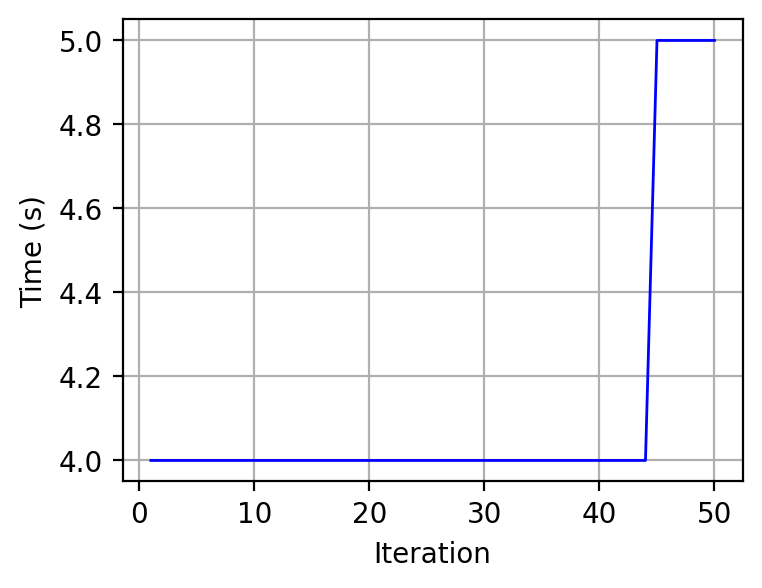

In [14]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 3

history['time_val'] = history['time_val'].astype(int)
history['time_avg'] = history['time_avg'].astype(int)

sns.lineplot(
    data=history,
    x='iter',
    y='time_val',
    zorder=2,
    c='b',
    linewidth=1,
)

plt.xlabel("Iteration")
plt.ylabel("Time (s)")
plt.grid(zorder=0)

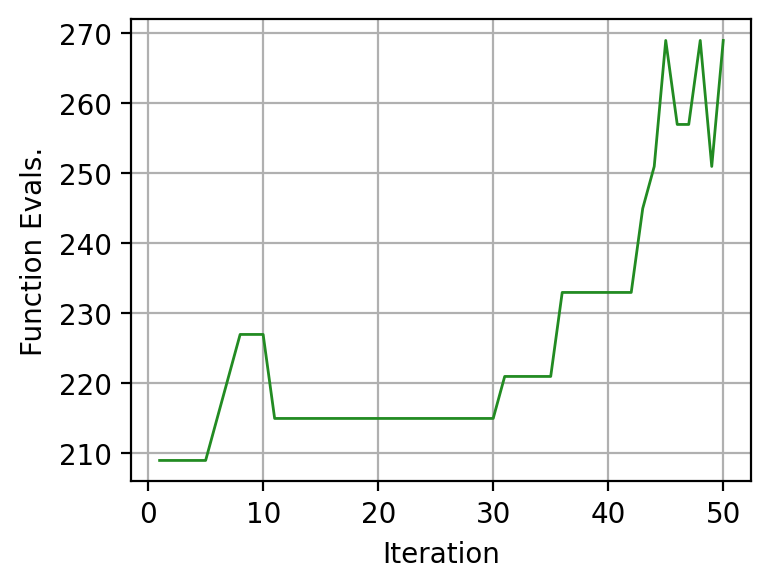

In [15]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 3

sns.lineplot(
    data=history,
    x='iter',
    y='nfe_total',
    zorder=2,
    c='forestgreen',
    linewidth=1,
)

plt.xlabel("Iteration")
plt.ylabel("Function Evals.")
plt.grid(zorder=0)

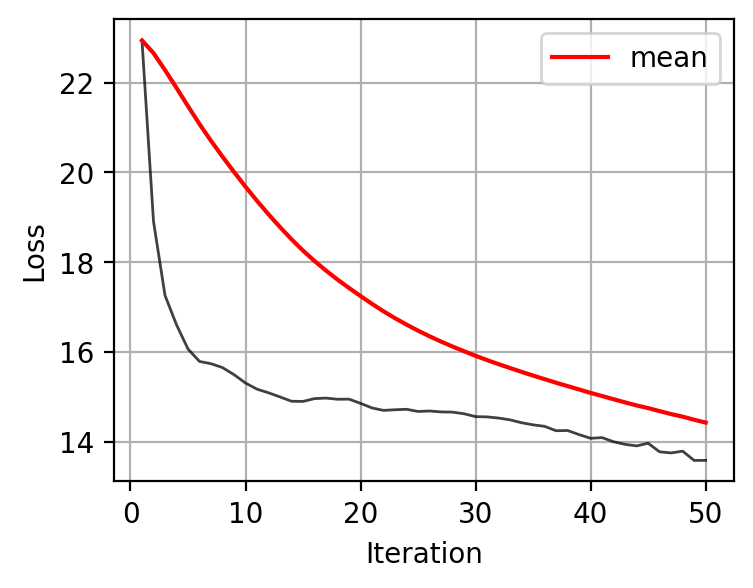

In [16]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 3

sns.lineplot(
    data=history,
    x='iter',
    y='loss_val',
    c='k', alpha=0.75, lw=1,
)

sns.lineplot(
    data=history,
    x='iter',
    y='loss_avg',
    label='mean',
    c='r', lw=1.5,
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.legend()

plt.show()

In [17]:
# break

# Integrate Backwards

In [18]:
%%time
def integrate_backwards(
    model, args, ntimes=100, device="cpu",
):
    torch.cuda.empty_cache()          
    # pluck end samples
    end_samples = args.data.get_data()[
        args.data.get_times() == np.max(args.data.get_times())
    ]
    
    with torch.no_grad():
        z = torch.from_numpy(end_samples).type(torch.float32).to(device)
        zero = torch.zeros(z.shape[0], 1).to(z)
        cnf = model.chain[0]

        zs = [z]
        deltas = []
        int_tps = np.linspace(args.int_tps[0], args.int_tps[-1], ntimes)
        
        for i, itp in enumerate(int_tps[::-1][:-1]):
            # tp counts down from last
            timescale = int_tps[1] - int_tps[0]
            integration_times = torch.tensor([itp - timescale, itp])
            # integration_times = torch.tensor([np.linspace(itp - args.time_scale, itp, ntimes)])
            integration_times = integration_times.type(torch.float32).to(device)

            # transform to previous timepoint
            z, delta_logp = cnf(zs[-1], zero, integration_times=integration_times)
            zs.append(z)
            deltas.append(delta_logp)
            
        zs = torch.stack(zs, 0)
        return zs.cpu().numpy()


data = integrate_backwards(
    model=model, 
    args=args,
    ntimes=100,
    device=device,
)

timepoints, cells, components = data.shape
print(f"{data.shape=}")
print(f"\t{timepoints=}")
print(f"\t{cells=}")
print(f"\t{components=}")

data.shape=(100, 1149, 10)
	timepoints=100
	cells=1149
	components=10
CPU times: user 3.82 s, sys: 128 ms, total: 3.95 s
Wall time: 3.97 s


# Visualize

sampled_cell=199


/tmp/ipykernel_1951328/1741855541.py:8: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(


Text(0, 0.5, 'PC 2')

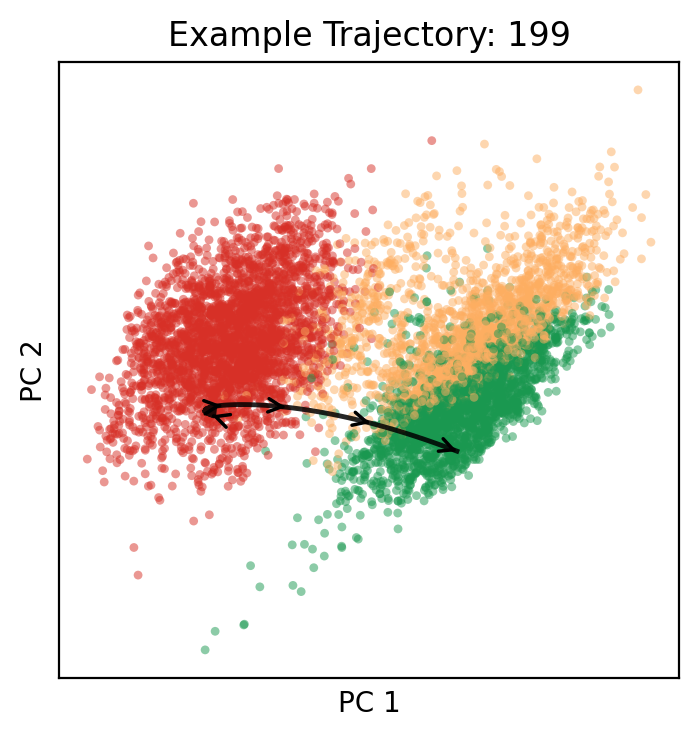

In [19]:
whitened_data = args.data.get_data()
x = whitened_data[:, 0]
y = whitened_data[:, 1]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sns.scatterplot(
    x=x, y=y, s=10, ec='none',
    hue=adata.obs['cluster_phase'], 
    palette=adata.uns['cluster_phase_colors'],
    alpha=0.5, legend=False,
)

sampled_cell = np.random.randint(0, cells)
print(f"{sampled_cell=}")

df = pd.DataFrame(data[:, sampled_cell, :2], columns=['comp1', 'comp2'])
df = df.reset_index(names='time')

sns.lineplot(
    data=df, 
    x='comp1', 
    y='comp2', 
    c='k', lw=1.75,
    alpha=0.85,
)

# arrows pointing the other direction (reverse along the path)
ax = plt.gca()
xy = df[['comp1','comp2']].to_numpy()

k = 5
if len(xy) > 1:
    idx = np.linspace(1, len(xy)-1, num=min(k, len(xy)-1), dtype=int)
    for i in idx:
        ax.annotate(
            '', xy=xy[i-1], xytext=xy[i],   # reversed
            arrowprops=dict(arrowstyle='->', lw=1.25, color='k', mutation_scale=12),
            zorder=5
        )
        
plt.title(f'Example Trajectory: {sampled_cell}')
plt.xticks([])
plt.yticks([])
plt.xlabel("PC 1")
plt.ylabel("PC 2")

# Vizualize all

/tmp/ipykernel_1951328/1579627919.py:8: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(


Text(0, 0.5, 'PC 2')

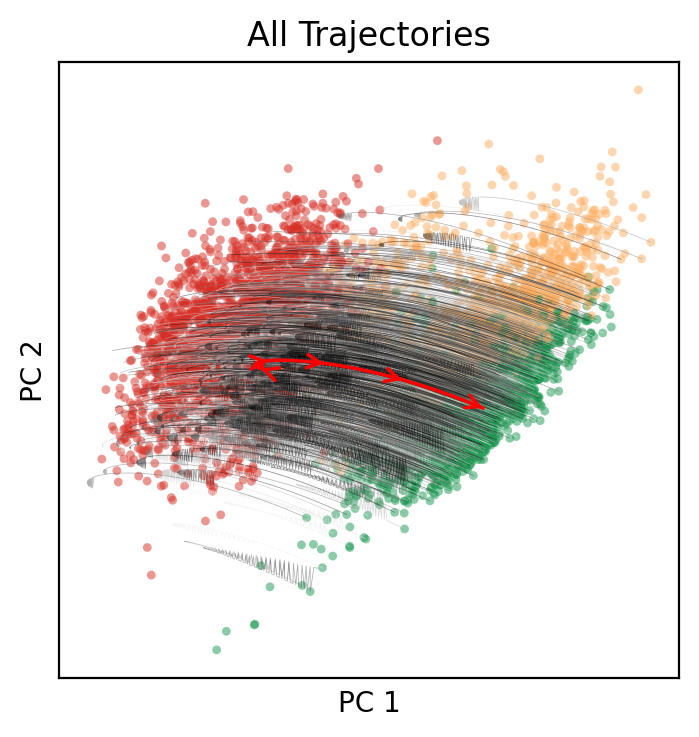

In [20]:
whitened_data = args.data.get_data()
x = whitened_data[:, 0]
y = whitened_data[:, 1]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sns.scatterplot(
    x=x, y=y, s=10, ec='none',
    hue=adata.obs['cluster_phase'], 
    palette=adata.uns['cluster_phase_colors'],
    alpha=0.5, legend=False,
)

# Build DataFrame
df = pd.DataFrame(
    data.reshape(timepoints * cells, components),
    columns=[f"comp{i+1}" for i in range(components)]
)

# Add metadata columns
df["timepoint"] = np.repeat(np.arange(timepoints), cells)
df["cell_id"] = np.tile(np.arange(cells), timepoints)

sns.lineplot(
    data=df,
    x='comp1',
    y='comp2',
    hue='cell_id',
    lw=0.25, alpha=0.5,
    palette='Greys',
    legend=False,
)

# mean trajectory
gx = df.groupby('timepoint')[['comp1', 'comp2']].mean().reset_index()

sns.lineplot(
    data=gx,
    x='comp1',
    y='comp2',
    lw=1.25,
    color='r',
    legend=False,
)

# arrows pointing the other direction (reverse along the path)
ax = plt.gca()
xy = gx[['comp1','comp2']].to_numpy()

k = 5
if len(xy) > 1:
    idx = np.linspace(1, len(xy)-1, num=min(k, len(xy)-1), dtype=int)
    for i in idx:
        ax.annotate(
            '', xy=xy[i-1], xytext=xy[i],   # reversed
            arrowprops=dict(arrowstyle='->', lw=1.25, color='r', mutation_scale=12),
            zorder=5
        )

plt.title(f'All Trajectories')
plt.xticks([])
plt.yticks([])
plt.xlabel("PC 1")
plt.ylabel("PC 2")

In [21]:
def infer_vector_field(traj, n_neighbors=20, grid_size=40, step=1):
    """
    Infer v(x,y) from trajectories by local regression.
    traj: array of shape (T, C, 2) with positions over time.
    n_neighbors: K in KNN; larger -> smoother field.
    grid_size: number of points per axis for the output grid.
    step: time stride for finite difference (Δt = step).
    Returns: Xg, Yg, U, V, knn (fitted regressor)
    """
    assert traj.ndim == 3 and traj.shape[2] == 2, "traj must be (T, C, 2)"
    T, C, _ = traj.shape
    assert step >= 1 and step < T, "step must be in [1, T-1]"

    # positions at t and velocities (x_{t+step} - x_t) / step
    P = traj[:-step].reshape(-1, 2)                         # ( (T-step)*C, 2 )
    V = (traj[step:] - traj[:-step]).reshape(-1, 2) / step  # same shape
    V = -V

    # fit a multi-output KNN regressor: (x,y) -> (vx, vy)
    knn = KNeighborsRegressor(n_neighbors=n_neighbors, weights="distance")
    knn.fit(P, V)

    # grid over data support with small padding
    mins = P.min(axis=0); maxs = P.max(axis=0)
    span = maxs - mins
    pad = 0.05 * np.max(span)
    x_lin = np.linspace(mins[0]-pad, maxs[0]+pad, grid_size)
    y_lin = np.linspace(mins[1]-pad, maxs[1]+pad, grid_size)
    Xg, Yg = np.meshgrid(x_lin, y_lin)
    G = np.c_[Xg.ravel(), Yg.ravel()]

    UV = knn.predict(G)
    U = UV[:, 0].reshape(grid_size, grid_size)
    Vv = UV[:, 1].reshape(grid_size, grid_size)
    return Xg, Yg, U, Vv, knn

In [22]:


# """ DEVELOP """
# whitened_data = args.data.get_data()
# x = whitened_data[:, 0]
# y = whitened_data[:, 1]

# sample_size = 200

# traj = data.copy()
# traj = traj[:, :, 0:2]
# print(f"raw: {traj.shape=}")

# cell_idx = np.random.choice(
#     range(traj.shape[1]), 
#     sample_size, 
#     replace=False,
# )

# traj = traj[:, cell_idx, :]
# print(f"sampled: {traj.shape=}")
# Xg, Yg, U, V, model = infer_vector_field(
#     traj, 
#     n_neighbors=55, 
#     grid_size=35, 
#     step=3,
# )

# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = (4, 4)

# fig, ax = plt.subplots()

# sns.kdeplot(
#     x=x, y=y,
#     hue=adata.obs['cluster_phase'],
#     palette=adata.uns['cluster_phase_colors'],
#     legend=False, 
#     alpha=0.35,
#     fill=True,
#     linewidths=0, 
#     levels=5,          # more bands -> smoother visual
#     bw_adjust=3.0,      # ↑ bandwidth = smoother/blurrier
#     cut=0,              # avoid edge overshoot
#     thresh=0.01,        # hide tiny tails
#     ax=ax
# )

# ax.quiver(
#     Xg, Yg, U, V, 
#     angles='xy', 
#     scale_units='xy', 
#     scale=0.35,
#     pivot='tail', 
#     headlength=3,
#     headwidth=3,
# )

# plt.xticks([])
# plt.yticks([])
# sns.despine(bottom=True, left=True)

In [ ]:
whitened_data = args.data.get_data()
x = whitened_data[:, 0]
y = whitened_data[:, 1]

sample_size = 500
n_neighbors = 5
grid_size = 35
step = 1
scale = 0.28


traj = data.copy()
traj = traj[:, :, 0:2]
print(f"raw: {traj.shape=}")

cell_idx = np.random.choice(
    range(traj.shape[1]), 
    sample_size, 
    replace=False,
)

traj = traj[:, cell_idx, :]
print(f"sampled: {traj.shape=}")
Xg, Yg, U, V, model = infer_vector_field(
    traj, 
    n_neighbors=n_neighbors, 
    grid_size=grid_size, 
    step=step,
)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (4, 4)

fig, ax = plt.subplots()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sns.scatterplot(
    x=x, 
    y=y, s=4, 
    ec='none',
    hue=adata.obs['cluster_phase'], 
    palette=adata.uns['cluster_phase_colors'],
    alpha=0.35,
    legend=False,
    ax=ax,
)

ax.quiver(
    Xg, Yg, U, V, 
    angles='xy', 
    scale_units='xy', 
    scale=scale,
    pivot='tail', 
    color='k',
    alpha=0.8,
    headwidth=2.5,
)

# ---- bounds from data ----
xmin, xmax = np.nanmin(x), np.nanmax(x)
ymin, ymax = np.nanmin(y), np.nanmax(y)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

plt.xticks([])
plt.yticks([])
sns.despine(bottom=True, left=True)

In [24]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Translate to Gene Expression Space
Trajectories are whitened, so need to inverse transform before translating to gene space

In [ ]:
def unwhiten_mean_trajectory(data, dataset_path, embedding_name, scaler=None):
    """
    Compute the per-time mean in whitened PCA space and inverse-transform it
    back to original PCA units.

    Parameters
    ----------
    data : np.ndarray
        Array of shape (T, N, k) in WHITENED PCA space (e.g., T timepoints, N cells, k PCs).
    dataset_path : str
        Path to the NPZ file containing the ORIGINAL (unwhitened) PCA matrix.
    embedding_name : str
        Key inside the NPZ holding the original PCA matrix of shape (M, k).
    scaler : sklearn.preprocessing.StandardScaler, optional
        If provided, use this pre-fit scaler. Otherwise, fit on the NPZ matrix.

    Returns
    -------
    means_unwhitened : np.ndarray
        Array of shape (T, k) in ORIGINAL PCA units.
    scaler : StandardScaler
        The fitted scaler used for the inverse transform.

    Notes
    -----
    Manual inverse (equivalent to `scaler.inverse_transform(means)`):
        means_unwhitened = means * scaler.scale_ + scaler.mean_
    """
    # mean over cells → (T, k)
    means = data.mean(axis=1)

    # fit scaler on ORIGINAL (unwhitened) PCA data if not provided
    if scaler is None:
        raw = np.load(dataset_path, allow_pickle=True)[embedding_name]
        scaler = StandardScaler().fit(raw)

    # inverse-transform to original PCA units
    means_unwhitened = scaler.inverse_transform(means)
    return means_unwhitened, scaler

# Example:
means, scaler = unwhiten_mean_trajectory(
    data, 
    args.dataset, 
    args.embedding_name,
)

print(f"{means.shape=}")

In [ ]:
%%time
def pca_to_gene(adata, scores, times=None, fill="nan"):
    """
    Back-project PCA scores to gene space and return a DataFrame.
    - scores: (T, k) array (e.g., means_unwhitened)
    - times: optional index of length T; defaults to range(T)
    - fill: "nan" (default) or "mean" for genes not used in PCA
    Columns are adata.var_names (all genes).
    """
    T, k = scores.shape
    vt = adata.varm["PCs"][:, :k]  # loadings: (n_vars_used, k) or (n_vars, k)

    # PCA settings
    pca_uns = adata.uns.get("pca", {})
    params = pca_uns.get("params", {})
    zero_center = bool(params.get("zero_center", True))

    # Matrix PCA was computed on (for means)
    X = adata.layers[params["layer"]] if params.get("layer") in adata.layers else adata.X
    if ss.issparse(X):
        X = X.toarray()

    n_vars = adata.n_vars
    mask_var = params.get("mask_var", None)
    use_hv = bool(params.get("use_highly_variable", False))
    if use_hv and (mask_var in adata.var.columns):
        gmask = adata.var[mask_var].to_numpy().astype(bool)
    else:
        gmask = np.ones(n_vars, dtype=bool)

    used_idx = np.where(gmask)[0] if vt.shape[0] == gmask.sum() else np.arange(n_vars)

    # Means
    mu_stored = pca_uns.get("mean", None)
    if mu_stored is not None and len(mu_stored) == vt.shape[0]:
        mu_used = np.asarray(mu_stored).ravel()
    else:
        mu_used = X[:, used_idx].mean(axis=0)
        if ss.issparse(mu_used):
            mu_used = mu_used.A1
    mu_full = X.mean(axis=0) if zero_center else np.zeros(n_vars)

    # Reconstruct only for genes used by PCA
    recon_used = scores @ vt.T  # (T, k) @ (k, n_used) -> (T, n_used)
    if zero_center:
        recon_used = recon_used + mu_used

    # Assemble full matrix
    if fill == "mean":
        X_full = np.broadcast_to(mu_full, (T, n_vars)).copy()
    else:  # "nan"
        X_full = np.full((T, n_vars), np.nan, dtype=float)

    X_full[:, used_idx] = recon_used

    # DataFrame with proper labels
    if times is None:
        times = np.arange(T)
    df = pd.DataFrame(X_full, index=pd.Index(times, name="time"), columns=adata.var_names)
    return df

X_recon = pca_to_gene(adata, means)
print(f"{X_recon.shape=}")
X_recon.head()

# plot a few

In [ ]:
# Reverse BOTH the index order and the values (once, then plot)
X_rev = X_recon.iloc[::-1].copy()

gene_list = [
    'TOP2A',
    'CCND1',
    'CCNE2',
]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 2.75

for gene in gene_list:
    x = X_rev.index
    y = X_rev[gene].to_numpy()[::-1].astype(float)
    y_z = zscore(y, ddof=0, nan_policy='omit')          # z-scores
    sns.lineplot(x=x, y=np.nan_to_num(y_z, nan=0.0), label=gene, lw=1)


plt.grid(True, alpha=0.5)
plt.ylabel('Expression (zscore)')
plt.xlabel('Timepoint')
sns.move_legend(plt.gca(), loc='center right', bbox_to_anchor=(1.4, 0.5))

In [ ]:
cell_cycle_genes = [x.strip() for x in open('../resources/regev_lab_cell_cycle_genes.txt')]

s_genes = [x for x in cell_cycle_genes[:43] if x in adata.var_names]
g2m_genes = [x for x in cell_cycle_genes[43:] if x in adata.var_names]

print(s_genes)
print()
print(g2m_genes)

In [ ]:
# Reverse BOTH the index order and the values (once, then plot)
X_rev = X_recon.iloc[::-1].copy()

gene_list = [
    'UNG', 
    'CCND1',
    "CCND2",  
    "CCND3", 
     "TP53",
    'CHAF1B', 
     "CDK6",
    'MCM6',
    'CDCA7',
    'UBL4A',
    'STMP1',
    'BEX1',
    'RRM1', 
    'GINS2', 
    'DTL', 
    'DSCC1', 
    'BLM', 
    'PCNA',
    'TYMS',
    'TOP2A',
    'CCNE2',
    'CDK1',
    'NUSAP1', 
    'MCM5', 
    "E2F3",
    
    
]

pdf = X_rev[gene_list].T

# row-wise zscores
zs = zscore(pdf.to_numpy(), axis=1, nan_policy='omit')
pdf = pd.DataFrame(zs, index=pdf.index, columns=pdf.columns)


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 7

sns.heatmap(
    pdf,
    cmap='coolwarm',
    cbar_kws={'label': 'z-score' if zscore else 'Gene expression', 'location': "top", }
)

_ = plt.xticks([])
plt.gca().set_xticks([0, len(pdf.columns)])
plt.gca().set_xticklabels([0, 22], rotation=0)
plt.xlabel('Time (h)')

In [ ]:
plot_df = pdf.T.reset_index(drop=True).reset_index(names='Time')
plot_df = pd.melt(plot_df, id_vars='Time')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

sns.lineplot(
    data=plot_df,
    x='Time',
    y='value',
    hue='variable',
    palette='tab20',
)

plt.grid(True, alpha=0.5)
plt.ylabel('Expression (zscore)')
plt.xlabel('Timepoint')
sns.move_legend(
    plt.gca(), 
    title="",
    ncols=3,
    loc='center right', 
    bbox_to_anchor=(1.95, 0.5),
)

In [ ]:
%%time
query = 'CDCA7'
y = pdf.loc[query].values
X = X_rev.copy()

print(f"f{type(X)=} {X.shape=}")
print(f"f{type(y)=} {y.shape=}")

# Ensure y is 1D
y = y.ravel()

# Compute correlations for all columns at once
corrs = X.corrwith(pd.Series(y)).sort_values(ascending=False)
corrs.head(20)


In [ ]:
break

# Single-cells in Gene Space

In [ ]:
def unwhiten_trajectories(data, dataset_path, embedding_name, scaler=None):
    """
    Inverse-standardize all trajectories from WHITENED PCA space back to
    ORIGINAL PCA units.

    Parameters
    ----------
    data : np.ndarray
        Shape (T, N, k) in WHITENED PCA space.
    dataset_path : str
        Path to NPZ containing the ORIGINAL (unwhitened) PCA matrix.
    embedding_name : str
        Key holding the original PCA matrix of shape (M, k).
    scaler : sklearn.preprocessing.StandardScaler, optional
        Pre-fit scaler on the ORIGINAL PCA matrix. If None, it is fit here.

    Returns
    -------
    data_unwhitened : np.ndarray
        Shape (T, N, k) in ORIGINAL PCA units.
    scaler : StandardScaler
        The fitted scaler used for the inverse transform.

    Notes
    -----
    Manual inverse (equivalent to StandardScaler.inverse_transform):
        data_unwhitened = data * scaler.scale_ + scaler.mean_
    """
    # fit scaler on ORIGINAL (unwhitened) PCA data if not provided
    if scaler is None:
        raw = np.load(dataset_path, allow_pickle=True)[embedding_name]
        scaler = StandardScaler().fit(raw)

    # vectorized broadcast over last axis (k)
    data = np.asarray(data, dtype=float)
    data_unwhitened = data * scaler.scale_ + scaler.mean_
    return data_unwhitened, scaler


# Example:
all_trajs, scaler = unwhiten_trajectories(
    data, 
    args.dataset, 
    args.embedding_name,
)
print(f"{all_trajs.shape=}")  # (T, N, k)

In [ ]:
%%time

sample_size = 50
idx = range(sample_size)

results = []
for i in idx:
    traj = all_trajs[:, i, :]       
    X_recon = pca_to_gene(adata, traj)
    X_recon['cell_idx'] = i
    X_recon = X_recon.reset_index()
    
    results.append(X_recon)
    
results = pd.concat(results)
results['time_r'] = results['time'].iloc[::-1].to_numpy()
results.head()



In [ ]:
gene_list = ['TOP2A','CCND1','CCNE2']
cell_idx = 0

dfc = results[results['cell_idx'] == cell_idx]

fig, axes = plt.subplots(
    nrows=len(gene_list), ncols=1, sharex=True,
    figsize=(3, 4), dpi=200
)

# if only one row, make axes iterable
axes = axes if isinstance(axes, (list, np.ndarray)) else [axes]

for ax, gene in zip(axes, gene_list):
    sns.lineplot(data=dfc, x='time_r', y=gene, ax=ax,
                 color='r', alpha=0.85, lw=1, legend=False)
    ax.set_title(gene, loc='left')
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.set_xticklabels([])
    sns.despine(ax=ax)

# x-label only on the bottom plot
for ax in axes[:-1]:
    ax.set_xlabel('')
axes[-1].set_xlabel('Time')

fig.tight_layout()
plt.show()

In [ ]:
break

# Analyze Reconstructions

In [ ]:
# genes present in X_recon
cell_cycle_genes = [x.strip() for x in open('../resources/regev_lab_cell_cycle_genes.txt')]
genes = [g for g in cell_cycle_genes if g in X_recon.columns]

Df = X_recon[genes]

# numeric index for correlation (fallback to 0..T-1)
try:
    t = pd.to_numeric(Df.index).to_numpy(dtype=float)
except Exception:
    t = np.arange(len(Df), dtype=float)

# compute Pearson r (per gene) vs index
rows = []
for g in genes:
    y = pd.to_numeric(Df[g], errors='coerce').to_numpy(dtype=float)
    m = np.isfinite(y) & np.isfinite(t)
    r, p = (pearsonr(t[m], y[m]) if m.sum() >= 3 else (np.nan, np.nan))
    rows.append((g, r, p))

corr = pd.DataFrame(rows, columns=["gene", "pearson_r", "pval"]).set_index("gene")

# rankings
rank_by_r   = corr.sort_values("pearson_r", ascending=False)                # most positive
rank_by_abs = corr.reindex(corr["pearson_r"].abs().sort_values(ascending=False).index)  # strongest

# show
print(rank_by_r.head(10))
print(rank_by_abs.head(10))


In [ ]:
# Reverse BOTH the index order and the values (once, then plot)
X_rev = X_recon.iloc[::-1].copy()

gene_list = rank_by_r.head(10).index

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 2.75

for gene in gene_list:
    x = X_rev.index
    y = X_rev[gene].to_numpy()[::-1].astype(float)
    y_z = zscore(y, ddof=0, nan_policy='omit')          # z-scores
    sns.lineplot(x=x, y=np.nan_to_num(y_z, nan=0.0), label=gene, lw=1)


plt.grid(True)
plt.ylabel('Expression (zscore)')
plt.xlabel('Timepoint')
sns.move_legend(plt.gca(), loc='center right', bbox_to_anchor=(1.5, 0.5))